# [DL] Neural Networks

### *Instructions:*
- **과제 명세서를 읽어주시고 코드 작성을 해주시길 바랍니다**</span> 
- **명시된 step을 따라가며 전체적인 학습 방법을 숙지합니다**</span>
- (**첫 번째 cell 결과로 나온 시간을 기준으로 채점을 하겠습니다**</span>).



In [1]:
import datetime
print("This code is run at " + str(datetime.datetime.now()))

This code is run at 2026-07-30 23:18:47.429408


In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from mlp import MultiLayerPerceptron
import utils

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

Matplotlib is building the font cache; this may take a moment.


## Problem

Mutilayer Perceptron(```class MutiLayerPerceptron```)으로 간단한 Binary classification task를 진행해봅시다.

> 1. **Dataset**
>> $\texttt{moon}$ dataset

> 2. **Network architecture**
$$
H_1=XW_1+b_1,\qquad z_1=\mathrm{ReLU}(H_1)
$$

$$
H_2=z_1W_2+b_2,\qquad z_2=\mathrm{LeakyReLU}(H_2)
$$

$$
H_3=z_2W_3+b_3,\qquad z_3=\tanh(H_3+H_1)
$$

$$
H_4=z_3W_4+b_4,\qquad \hat y=\sigma(H_4)
$$
 > $ReLU$ $=\max(0,x)$ 
 
 > $LeakyReLU(H_2)$ $=\max(0.01x,x)$ 

 
 > **$W$** and **$b$** 는 각각 weights와 bias.    
 > **weight 초기화**: Standard normal ($\texttt{np.random.randn}$. 사용)  
 > **bias 초기화(intercept)**: 0     
 > **Input size**: 2  
 > **The first hidden layer size**: 10  
 > **The second hidden layer size**: 10  
 > **Output size**: 1   
 > **Regularization parameter $\lambda$**: 0.001  
 > **Loss function**: Binary cross entropy loss (or equivently log loss).  
 > **Total loss** : 
 > $L_{total} = \sum_{i=1}^N{ (-y^{(i)}\log \hat{y}^{(i)} -(1-y^{(i)})\log(1-\hat{y}^{(i)})) } +  \lambda \|W\|^2 $   
 > **Optimization**: Gradient descent  
 > **Learning rate** = 0.0001  
 > **Number of epochs** = 50000  
 > $y$는 정답, $\hat{y}$는 예측값이고 0부터 1사이에 존재한다.  

### STEP 1. 데이터 준비

비교 실험을 위해 train/validation set을 분리합니다.

STEP 1: Load data


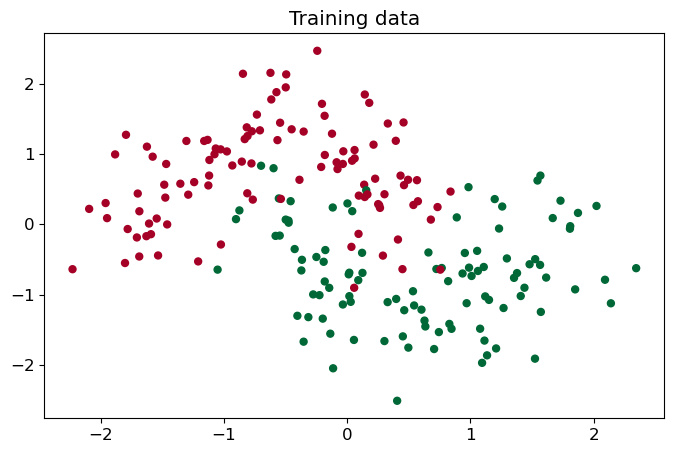

train: (210, 2) validation: (90, 2)


In [3]:
print("STEP 1: Load data")

# Load data
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Visualize data
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=25, cmap=plt.cm.RdYlGn)
plt.title("Training data")
plt.show()

print("train:", X_train.shape, "validation:", X_val.shape)

## STEP 2. 기본 모델 학습

`mlp.py`의 TODO를 모두 구현한 뒤 아래 셀을 실행하세요.

STEP 2: Train the model
[bgd] epoch=100, train_loss=86.4001, train_acc=0.810
[bgd] epoch=200, train_loss=75.9894, train_acc=0.871
[bgd] epoch=300, train_loss=69.5096, train_acc=0.895
[bgd] epoch=400, train_loss=64.4193, train_acc=0.914
[bgd] epoch=500, train_loss=58.7299, train_acc=0.910
[bgd] epoch=600, train_loss=53.0578, train_acc=0.924
[bgd] epoch=700, train_loss=49.0516, train_acc=0.929
[bgd] epoch=800, train_loss=46.2263, train_acc=0.933
[bgd] epoch=900, train_loss=43.9536, train_acc=0.938
[bgd] epoch=1000, train_loss=41.9957, train_acc=0.938
[bgd] epoch=1100, train_loss=40.2426, train_acc=0.943
[bgd] epoch=1200, train_loss=38.6305, train_acc=0.948
[bgd] epoch=1300, train_loss=37.1382, train_acc=0.952
[bgd] epoch=1400, train_loss=35.8192, train_acc=0.952
[bgd] epoch=1500, train_loss=34.6701, train_acc=0.957
[bgd] epoch=1600, train_loss=33.6805, train_acc=0.957
[bgd] epoch=1700, train_loss=32.7792, train_acc=0.957
[bgd] epoch=1800, train_loss=31.9337, train_acc=0.957
[bgd] epoch=1

[bgd] epoch=2100, train_loss=29.8660, train_acc=0.962
[bgd] epoch=2200, train_loss=29.2811, train_acc=0.962


[bgd] epoch=2300, train_loss=28.7368, train_acc=0.962
[bgd] epoch=2400, train_loss=28.2287, train_acc=0.962
[bgd] epoch=2500, train_loss=27.7564, train_acc=0.962
[bgd] epoch=2600, train_loss=27.3106, train_acc=0.957
[bgd] epoch=2700, train_loss=26.8718, train_acc=0.957
[bgd] epoch=2800, train_loss=26.4738, train_acc=0.957
[bgd] epoch=2900, train_loss=26.0958, train_acc=0.957
[bgd] epoch=3000, train_loss=25.7364, train_acc=0.957
[bgd] epoch=3100, train_loss=25.3827, train_acc=0.962
[bgd] epoch=3200, train_loss=25.0261, train_acc=0.962
[bgd] epoch=3300, train_loss=24.6531, train_acc=0.962
[bgd] epoch=3400, train_loss=24.2658, train_acc=0.962
[bgd] epoch=3500, train_loss=23.8648, train_acc=0.962
[bgd] epoch=3600, train_loss=23.4924, train_acc=0.962
[bgd] epoch=3700, train_loss=23.1565, train_acc=0.962
[bgd] epoch=3800, train_loss=22.8572, train_acc=0.962
[bgd] epoch=3900, train_loss=22.5819, train_acc=0.962
[bgd] epoch=4000, train_loss=22.3246, train_acc=0.962
[bgd] epoch=4100, train_loss

[bgd] epoch=4500, train_loss=21.2191, train_acc=0.967
[bgd] epoch=4600, train_loss=21.0195, train_acc=0.967


[bgd] epoch=4700, train_loss=20.8258, train_acc=0.967
[bgd] epoch=4800, train_loss=20.6381, train_acc=0.967
[bgd] epoch=4900, train_loss=20.4602, train_acc=0.967
[bgd] epoch=5000, train_loss=20.2865, train_acc=0.967
[bgd] epoch=5100, train_loss=20.1078, train_acc=0.967
[bgd] epoch=5200, train_loss=19.9371, train_acc=0.967
[bgd] epoch=5300, train_loss=19.7667, train_acc=0.967
[bgd] epoch=5400, train_loss=19.5887, train_acc=0.967
[bgd] epoch=5500, train_loss=19.4219, train_acc=0.967
[bgd] epoch=5600, train_loss=19.2606, train_acc=0.967
[bgd] epoch=5700, train_loss=19.1017, train_acc=0.967
[bgd] epoch=5800, train_loss=18.9516, train_acc=0.967
[bgd] epoch=5900, train_loss=18.8017, train_acc=0.967
[bgd] epoch=6000, train_loss=18.6488, train_acc=0.967
[bgd] epoch=6100, train_loss=18.5096, train_acc=0.967
[bgd] epoch=6200, train_loss=18.3650, train_acc=0.967
[bgd] epoch=6300, train_loss=18.2327, train_acc=0.967
[bgd] epoch=6400, train_loss=18.0945, train_acc=0.967
[bgd] epoch=6500, train_loss

...

[bgd] epoch=43100, train_loss=4.7299, train_acc=0.986
[bgd] epoch=43200, train_loss=4.7230, train_acc=0.986
[bgd] epoch=43300, train_loss=4.7151, train_acc=0.986
[bgd] epoch=43400, train_loss=4.7081, train_acc=0.986
[bgd] epoch=43500, train_loss=4.7010, train_acc=0.986
[bgd] epoch=43600, train_loss=4.6914, train_acc=0.986
[bgd] epoch=43700, train_loss=4.6853, train_acc=0.986
[bgd] epoch=43800, train_loss=4.6829, train_acc=0.986
[bgd] epoch=43900, train_loss=4.6760, train_acc=0.986
[bgd] epoch=44000, train_loss=4.6664, train_acc=0.986
[bgd] epoch=44100, train_loss=4.6598, train_acc=0.986
[bgd] epoch=44200, train_loss=4.6589, train_acc=0.986
[bgd] epoch=44300, train_loss=4.6480, train_acc=0.986
[bgd] epoch=44400, train_loss=4.6437, train_acc=0.986
[bgd] epoch=44500, train_loss=4.6386, train_acc=0.986
[bgd] epoch=44600, train_loss=4.6278, train_acc=0.986
[bgd] epoch=44700, train_loss=4.6275, train_acc=0.986
[bgd] epoch=44800, train_loss=4.6166, train_acc=0.986
[bgd] epoch=44900, train_los

[bgd] epoch=45300, train_loss=4.5915, train_acc=0.986
[bgd] epoch=45400, train_loss=4.5810, train_acc=0.986


[bgd] epoch=45500, train_loss=4.5754, train_acc=0.986
[bgd] epoch=45600, train_loss=4.5746, train_acc=0.986
[bgd] epoch=45700, train_loss=4.5623, train_acc=0.986
[bgd] epoch=45800, train_loss=4.5613, train_acc=0.986
[bgd] epoch=45900, train_loss=4.5548, train_acc=0.986
[bgd] epoch=46000, train_loss=4.5465, train_acc=0.986
[bgd] epoch=46100, train_loss=4.5461, train_acc=0.986
[bgd] epoch=46200, train_loss=4.5344, train_acc=0.986
[bgd] epoch=46300, train_loss=4.5321, train_acc=0.986
[bgd] epoch=46400, train_loss=4.5294, train_acc=0.986
[bgd] epoch=46500, train_loss=4.5207, train_acc=0.986
[bgd] epoch=46600, train_loss=4.5126, train_acc=0.986
[bgd] epoch=46700, train_loss=4.5108, train_acc=0.986
[bgd] epoch=46800, train_loss=4.5079, train_acc=0.986
[bgd] epoch=46900, train_loss=4.4990, train_acc=0.986
[bgd] epoch=47000, train_loss=4.4906, train_acc=0.986
[bgd] epoch=47100, train_loss=4.4891, train_acc=0.986
[bgd] epoch=47200, train_loss=4.4845, train_acc=0.986
[bgd] epoch=47300, train_los

[bgd] epoch=47700, train_loss=4.4579, train_acc=0.986
[bgd] epoch=47800, train_loss=4.4550, train_acc=0.986


[bgd] epoch=47900, train_loss=4.4485, train_acc=0.986
[bgd] epoch=48000, train_loss=4.4416, train_acc=0.986
[bgd] epoch=48100, train_loss=4.4330, train_acc=0.986
[bgd] epoch=48200, train_loss=4.4287, train_acc=0.986
[bgd] epoch=48300, train_loss=4.4266, train_acc=0.986
[bgd] epoch=48400, train_loss=4.4225, train_acc=0.986
[bgd] epoch=48500, train_loss=4.4194, train_acc=0.986
[bgd] epoch=48600, train_loss=4.4137, train_acc=0.986
[bgd] epoch=48700, train_loss=4.4070, train_acc=0.986
[bgd] epoch=48800, train_loss=4.3996, train_acc=0.986
[bgd] epoch=48900, train_loss=4.3929, train_acc=0.986
[bgd] epoch=49000, train_loss=4.3886, train_acc=0.986
[bgd] epoch=49100, train_loss=4.3847, train_acc=0.986
[bgd] epoch=49200, train_loss=4.3825, train_acc=0.986
[bgd] epoch=49300, train_loss=4.3787, train_acc=0.986
[bgd] epoch=49400, train_loss=4.3755, train_acc=0.986
[bgd] epoch=49500, train_loss=4.3711, train_acc=0.986
[bgd] epoch=49600, train_loss=4.3642, train_acc=0.986
[bgd] epoch=49700, train_los

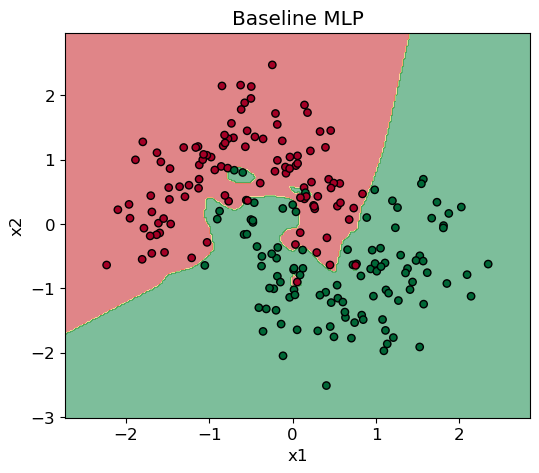

In [4]:
print("STEP 2: Train the model")
# random seed
np.random.seed(0)

# Hyperparameters
nn_input_dim = 2
nn_output_dim = 1
nn_hdim1 = 10
nn_hdim2 = 10
nn_hdim3 = 10
lr = 0.0001 
L2_norm = 0.001
epoch = 50000

model = MultiLayerPerceptron(nn_input_dim, nn_hdim1, nn_hdim2, nn_hdim3, nn_output_dim, init="random")
stats = model.train(X_train, y_train, learning_rate=lr, L2_norm=L2_norm, epoch=epoch, print_loss=True)
utils.plot_decision_boundary(model, X_train, y_train, "Baseline MLP")

## STEP 3. BGD vs SGD vs Mini-batch GD

아래 조건은 세 방법에서 동일하게 고정합니다.

- 동일한 model architecture 및 초기 weight seed
- 동일한 learning rate
- 동일한 epoch 수
- 동일한 train/validation data

In [5]:
print("STEP 3: Compare BGD, SGD, and Mini-batch GD")

# 세 실험에서는 optimizer와 batch_size만 변경합니다.

optimizer_settings = {
    "BGD": {
        "optimizer": "bgd",
        "batch_size": None,
    },
    "SGD": {
        "optimizer": "sgd",
        "batch_size": 1,
    },
    "Mini-batch": {
        "optimizer": "minibatch",
        "batch_size": 32,
    },
}

models = {}
histories = {}

for name, setting in optimizer_settings.items():

    model = MultiLayerPerceptron(
        nn_input_dim,
        nn_hdim1,
        nn_hdim2,
        nn_hdim3,
        nn_output_dim,
        init="random",
    )

    history = model.train(
        X_train,
        y_train,
        X_val,
        y_val,
        learning_rate=lr,
        L2_norm=L2_norm,
        epoch=10000, #step 3에서는 epoch 줄여서 실행
        optimizer=setting["optimizer"],
        batch_size=setting["batch_size"],
        seed=0,
        eval_every=5,
        print_loss=True,
    )

    models[name] = model
    histories[name] = history

utils.result_table(histories)

STEP 3: Compare BGD, SGD, and Mini-batch GD
[bgd] epoch=50, train_loss=100.8804, train_acc=0.800, val_loss=43.3482, val_acc=0.789
[bgd] epoch=100, train_loss=86.4001, train_acc=0.810, val_loss=38.0664, val_acc=0.800
[bgd] epoch=150, train_loss=80.2071, train_acc=0.814, val_loss=36.1744, val_acc=0.800
[bgd] epoch=200, train_loss=75.9894, train_acc=0.871, val_loss=34.9003, val_acc=0.833
[bgd] epoch=250, train_loss=72.4697, train_acc=0.890, val_loss=33.6763, val_acc=0.867
[bgd] epoch=300, train_loss=69.5096, train_acc=0.895, val_loss=32.5396, val_acc=0.867
[bgd] epoch=350, train_loss=66.8955, train_acc=0.895, val_loss=31.6341, val_acc=0.878
[bgd] epoch=400, train_loss=64.4193, train_acc=0.914, val_loss=30.8550, val_acc=0.878
[bgd] epoch=450, train_loss=61.8250, train_acc=0.914, val_loss=30.0760, val_acc=0.878
[bgd] epoch=500, train_loss=58.7299, train_acc=0.910, val_loss=29.2237, val_acc=0.878
[bgd] epoch=550, train_loss=55.7964, train_acc=0.910, val_loss=28.2835, val_acc=0.878
[bgd] epoc

[bgd] epoch=2000, train_loss=30.4872, train_acc=0.962, val_loss=19.4854, val_acc=0.900
[bgd] epoch=2050, train_loss=30.1700, train_acc=0.962, val_loss=19.4408, val_acc=0.900
[bgd] epoch=2100, train_loss=29.8660, train_acc=0.962, val_loss=19.4419, val_acc=0.900
[bgd] epoch=2150, train_loss=29.5684, train_acc=0.962, val_loss=19.4644, val_acc=0.900
[bgd] epoch=2200, train_loss=29.2811, train_acc=0.962, val_loss=19.4854, val_acc=0.900
[bgd] epoch=2250, train_loss=29.0042, train_acc=0.962, val_loss=19.5143, val_acc=0.900
[bgd] epoch=2300, train_loss=28.7368, train_acc=0.962, val_loss=19.5480, val_acc=0.900
[bgd] epoch=2350, train_loss=28.4780, train_acc=0.962, val_loss=19.5969, val_acc=0.900
[bgd] epoch=2400, train_loss=28.2287, train_acc=0.962, val_loss=19.6613, val_acc=0.900
[bgd] epoch=2450, train_loss=27.9887, train_acc=0.962, val_loss=19.7329, val_acc=0.900
[bgd] epoch=2500, train_loss=27.7564, train_acc=0.962, val_loss=19.8176, val_acc=0.900
[bgd] epoch=2550, train_loss=27.5295, train

[bgd] epoch=4000, train_loss=22.3246, train_acc=0.962, val_loss=22.8096, val_acc=0.922
[bgd] epoch=4050, train_loss=22.2022, train_acc=0.962, val_loss=22.8399, val_acc=0.922
[bgd] epoch=4100, train_loss=22.0879, train_acc=0.962, val_loss=22.8736, val_acc=0.922
[bgd] epoch=4150, train_loss=21.9710, train_acc=0.962, val_loss=22.9046, val_acc=0.922
[bgd] epoch=4200, train_loss=21.8536, train_acc=0.962, val_loss=22.9295, val_acc=0.922
[bgd] epoch=4250, train_loss=21.7474, train_acc=0.967, val_loss=22.9762, val_acc=0.922
[bgd] epoch=4300, train_loss=21.6356, train_acc=0.967, val_loss=23.0110, val_acc=0.922
[bgd] epoch=4350, train_loss=21.5254, train_acc=0.967, val_loss=23.0348, val_acc=0.933
[bgd] epoch=4400, train_loss=21.4206, train_acc=0.967, val_loss=23.0793, val_acc=0.933
[bgd] epoch=4450, train_loss=21.3159, train_acc=0.967, val_loss=23.1191, val_acc=0.933
[bgd] epoch=4500, train_loss=21.2191, train_acc=0.967, val_loss=23.1679, val_acc=0.933
[bgd] epoch=4550, train_loss=21.1189, train

[bgd] epoch=6050, train_loss=18.5778, train_acc=0.967, val_loss=25.0971, val_acc=0.933
[bgd] epoch=6100, train_loss=18.5096, train_acc=0.967, val_loss=25.1710, val_acc=0.922
[bgd] epoch=6150, train_loss=18.4337, train_acc=0.967, val_loss=25.2291, val_acc=0.922
[bgd] epoch=6200, train_loss=18.3650, train_acc=0.967, val_loss=25.2799, val_acc=0.922
[bgd] epoch=6250, train_loss=18.2997, train_acc=0.967, val_loss=25.3491, val_acc=0.922
[bgd] epoch=6300, train_loss=18.2327, train_acc=0.967, val_loss=25.4242, val_acc=0.922
[bgd] epoch=6350, train_loss=18.1610, train_acc=0.967, val_loss=25.5024, val_acc=0.922
[bgd] epoch=6400, train_loss=18.0945, train_acc=0.967, val_loss=25.5577, val_acc=0.922
[bgd] epoch=6450, train_loss=18.0330, train_acc=0.962, val_loss=25.6253, val_acc=0.922
[bgd] epoch=6500, train_loss=17.9666, train_acc=0.962, val_loss=25.6768, val_acc=0.922
[bgd] epoch=6550, train_loss=17.9036, train_acc=0.962, val_loss=25.7468, val_acc=0.922
[bgd] epoch=6600, train_loss=17.8358, train

[bgd] epoch=8100, train_loss=15.9580, train_acc=0.967, val_loss=27.6478, val_acc=0.911
[bgd] epoch=8150, train_loss=15.8999, train_acc=0.967, val_loss=27.7028, val_acc=0.911
[bgd] epoch=8200, train_loss=15.8337, train_acc=0.967, val_loss=27.7927, val_acc=0.911
[bgd] epoch=8250, train_loss=15.7829, train_acc=0.967, val_loss=27.8889, val_acc=0.911
[bgd] epoch=8300, train_loss=15.7276, train_acc=0.967, val_loss=27.9248, val_acc=0.922
[bgd] epoch=8350, train_loss=15.6556, train_acc=0.971, val_loss=27.9541, val_acc=0.922
[bgd] epoch=8400, train_loss=15.6076, train_acc=0.971, val_loss=28.0350, val_acc=0.922
[bgd] epoch=8450, train_loss=15.5426, train_acc=0.971, val_loss=28.1010, val_acc=0.922
[bgd] epoch=8500, train_loss=15.4538, train_acc=0.971, val_loss=28.1224, val_acc=0.922
[bgd] epoch=8550, train_loss=15.3769, train_acc=0.971, val_loss=28.1483, val_acc=0.922
[bgd] epoch=8600, train_loss=15.3105, train_acc=0.971, val_loss=28.1914, val_acc=0.922
[bgd] epoch=8650, train_loss=15.2506, train

...

[minibatch] epoch=7750, train_loss=16.4993, train_acc=0.967, val_loss=27.1567, val_acc=0.911
[minibatch] epoch=7800, train_loss=16.4580, train_acc=0.967, val_loss=27.1706, val_acc=0.911
[minibatch] epoch=7850, train_loss=16.3939, train_acc=0.967, val_loss=27.3038, val_acc=0.911
[minibatch] epoch=7900, train_loss=16.3363, train_acc=0.967, val_loss=27.3326, val_acc=0.911
[minibatch] epoch=7950, train_loss=16.2776, train_acc=0.967, val_loss=27.4123, val_acc=0.911
[minibatch] epoch=8000, train_loss=16.2250, train_acc=0.967, val_loss=27.4684, val_acc=0.911
[minibatch] epoch=8050, train_loss=16.1703, train_acc=0.967, val_loss=27.5308, val_acc=0.911
[minibatch] epoch=8100, train_loss=16.1101, train_acc=0.967, val_loss=27.5913, val_acc=0.911
[minibatch] epoch=8150, train_loss=16.0590, train_acc=0.967, val_loss=27.6111, val_acc=0.922
[minibatch] epoch=8200, train_loss=15.9981, train_acc=0.967, val_loss=27.6910, val_acc=0.922
[minibatch] epoch=8250, train_loss=15.9364, train_acc=0.971, val_loss=

[minibatch] epoch=8350, train_loss=15.8173, train_acc=0.971, val_loss=27.8298, val_acc=0.922
[minibatch] epoch=8400, train_loss=15.7735, train_acc=0.971, val_loss=27.8545, val_acc=0.922
[minibatch] epoch=8450, train_loss=15.7041, train_acc=0.971, val_loss=27.9370, val_acc=0.922
[minibatch] epoch=8500, train_loss=15.6476, train_acc=0.971, val_loss=27.9228, val_acc=0.922
[minibatch] epoch=8550, train_loss=15.5860, train_acc=0.971, val_loss=28.0101, val_acc=0.922
[minibatch] epoch=8600, train_loss=15.5397, train_acc=0.971, val_loss=28.0067, val_acc=0.922
[minibatch] epoch=8650, train_loss=15.4403, train_acc=0.971, val_loss=28.1149, val_acc=0.922
[minibatch] epoch=8700, train_loss=15.3639, train_acc=0.971, val_loss=28.1067, val_acc=0.922
[minibatch] epoch=8750, train_loss=15.3031, train_acc=0.971, val_loss=28.1280, val_acc=0.922
[minibatch] epoch=8800, train_loss=15.2459, train_acc=0.971, val_loss=28.1941, val_acc=0.922
[minibatch] epoch=8850, train_loss=15.1834, train_acc=0.971, val_loss=

[minibatch] epoch=8950, train_loss=15.0651, train_acc=0.971, val_loss=28.3048, val_acc=0.922
[minibatch] epoch=9000, train_loss=15.0062, train_acc=0.971, val_loss=28.3035, val_acc=0.922
[minibatch] epoch=9050, train_loss=14.9619, train_acc=0.971, val_loss=28.3231, val_acc=0.922
[minibatch] epoch=9100, train_loss=14.8799, train_acc=0.971, val_loss=28.3956, val_acc=0.922
[minibatch] epoch=9150, train_loss=14.8209, train_acc=0.971, val_loss=28.4584, val_acc=0.922
[minibatch] epoch=9200, train_loss=14.7618, train_acc=0.971, val_loss=28.5232, val_acc=0.922
[minibatch] epoch=9250, train_loss=14.7019, train_acc=0.971, val_loss=28.5786, val_acc=0.922
[minibatch] epoch=9300, train_loss=14.6474, train_acc=0.971, val_loss=28.6232, val_acc=0.922
[minibatch] epoch=9350, train_loss=14.5823, train_acc=0.971, val_loss=28.6654, val_acc=0.922
[minibatch] epoch=9400, train_loss=14.5217, train_acc=0.971, val_loss=28.6825, val_acc=0.922
[minibatch] epoch=9450, train_loss=14.4715, train_acc=0.971, val_loss=

[minibatch] epoch=9600, train_loss=14.2982, train_acc=0.971, val_loss=28.8244, val_acc=0.922
[minibatch] epoch=9650, train_loss=14.2338, train_acc=0.971, val_loss=28.8751, val_acc=0.922
[minibatch] epoch=9700, train_loss=14.1781, train_acc=0.971, val_loss=28.9773, val_acc=0.922
[minibatch] epoch=9750, train_loss=14.1228, train_acc=0.971, val_loss=29.0268, val_acc=0.922
[minibatch] epoch=9800, train_loss=14.0639, train_acc=0.971, val_loss=29.0583, val_acc=0.922
[minibatch] epoch=9850, train_loss=14.0041, train_acc=0.971, val_loss=29.1102, val_acc=0.922
[minibatch] epoch=9900, train_loss=13.9510, train_acc=0.971, val_loss=29.1722, val_acc=0.922
[minibatch] epoch=9950, train_loss=13.9027, train_acc=0.971, val_loss=29.1543, val_acc=0.922
[minibatch] epoch=10000, train_loss=13.8417, train_acc=0.971, val_loss=29.2324, val_acc=0.922


,experiment,updates,elapsed_sec,final_train_loss,final_train_acc,final_val_loss,final_val_acc
0,BGD,10000,1.009236,13.598985,0.971429,29.455395,0.922222
1,SGD,2100000,78.916898,21.512876,0.966667,23.157484,0.900000
2,Mini-batch,70000,3.391879,13.841743,0.971429,29.232358,0.922222


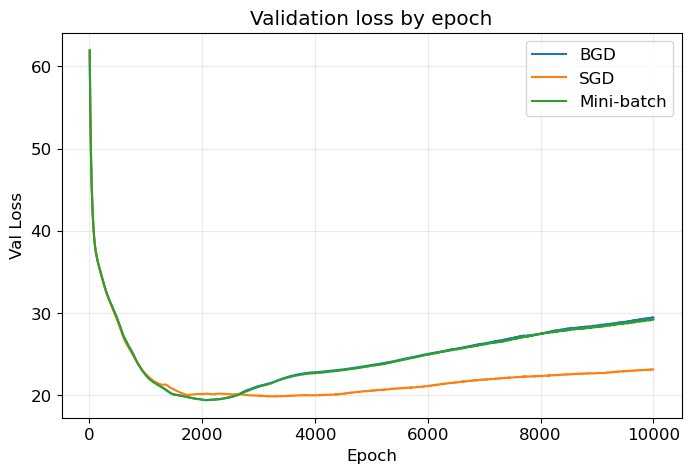

In [6]:
utils.plot_optimizer_histories(
    histories, x_axis="epoch", metric="val_loss",
    title="Validation loss by epoch"
)

## STEP 4. 하이퍼파라미터 탐색

BGD, SGD, Mini-batch GD 중 **하나를 선택**하여 여러 하이퍼파라미터 조합을 자유롭게 실험해봅시다.

변경 가능한 예시:

- learning rate
- epoch
- hidden dimension
- batch size
- L2 regularization strength
- initialization seed

최소 3개 이상의 조합을 시도하고, 아래에 기록하시면 됩니다.

In [7]:
print("STEP 4: Hyperparameter Tuning")

# 업데이트가 안정적이고 계산량도 적당한 Mini-batch GD를 선택했습니다.
chosen_optimizer = "minibatch"

trial_configs = [
    {
        "name": "small_lr",
        "lr": 5e-4,
        "epoch": 500,
        "hidden": 10,
        "batch_size": 32,
        "l2": 0.0,
    },
    {
        "name": "large_model",
        "lr": 1e-3,
        "epoch": 500,
        "hidden": 20,
        "batch_size": 32,
        "l2": 0.0,
    },
    {
        "name": "regularized",
        "lr": 1e-3,
        "epoch": 500,
        "hidden": 20,
        "batch_size": 64,
        "l2": 1e-4,
    },
]

trial_models = {}
trial_histories = {}

for cfg in trial_configs:

    model = MultiLayerPerceptron(
        nn_input_dim,
        cfg["hidden"],
        cfg["hidden"],
        cfg["hidden"],
        nn_output_dim,
        init="random",
    )

    history = model.train(
        X_train,
        y_train,
        X_val,
        y_val,
        learning_rate=cfg["lr"],
        L2_norm=cfg["l2"],
        epoch=cfg["epoch"],
        optimizer=chosen_optimizer,
        batch_size=cfg["batch_size"],
        seed=0,
        eval_every=max(1, cfg["epoch"] // 100),
        print_loss=False,
    )

    trial_models[cfg["name"]] = model
    trial_histories[cfg["name"]] = history

utils.result_table(trial_histories)

STEP 4: Hyperparameter Tuning


,experiment,updates,elapsed_sec,final_train_loss,final_train_acc,final_val_loss,final_val_acc
0,small_lr,3500,0.180798,28.193304,0.952381,19.070474,0.933333
1,large_model,3500,0.197846,13.868326,0.961905,35.269631,0.866667
2,regularized,2000,0.141178,12.674450,0.980952,26.916621,0.900000


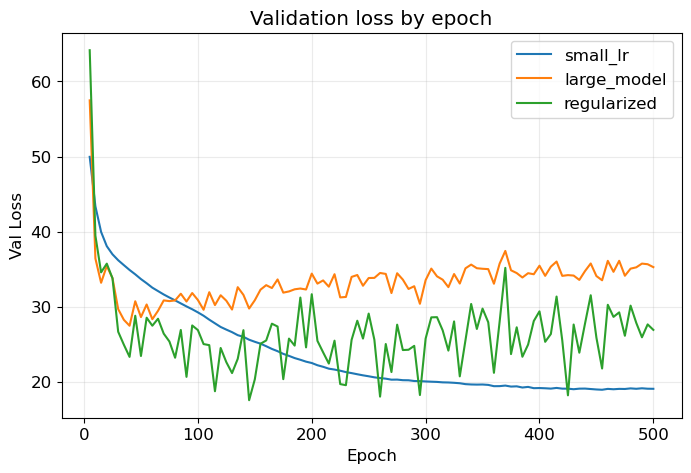

In [8]:
utils.plot_optimizer_histories(
    trial_histories, x_axis="epoch", metric="val_loss",
    title="Validation loss by epoch"
)

### STEP 4 시도 내용 및 해석

본인이 시도한 하이퍼파라미터 튜닝 방법에 대해서 자유롭게 기술해주세요. 

ex: 어떤 하이퍼파라미터를 왜 변경했는지, 해당 변경이 모델의 성능이나 학습 시간에 어떤 영향을 미쳤는지 등

(시도한 방법의 성능이 반드시 좋아야 하는 것은 아닙니다. 다양한 하이퍼파라미터를 직접 변경하며 결과를 비교·분석하는 것이 목표이며, 최종 성능 자체는 채점에 반영되지 않습니다.)

> **시도 내용 및 결과 해석:**  

> 세 실험 모두 Mini-batch GD와 500 epoch를 사용하고 learning rate, hidden dimension, batch size, L2 규제를 바꾸어 비교했다. `small_lr`는 작은 모델(hidden=10)과 낮은 learning rate(5e-4)를 사용하여 가장 안정적인 기준을 만들었다. 그 결과 train accuracy는 0.952, validation accuracy는 0.933이었다. `large_model`은 learning rate를 1e-3으로 높이고 hidden dimension을 20으로 늘렸다. train accuracy는 0.962로 상승했지만 validation accuracy는 0.867로 낮아지고 validation loss도 커져, 표현력이 큰 모델이 학습 데이터에 더 강하게 맞춰진 것으로 보인다. `regularized`는 큰 모델에 L2=1e-4를 추가하고 batch size를 64로 늘렸다. validation accuracy가 0.900으로 `large_model`보다 회복되었고, epoch당 update 수가 줄어 실행 시간도 감소했다. 따라서 이 데이터에서는 가장 복잡한 모델보다 낮은 learning rate의 작은 모델이 일반화 성능이 가장 좋았으며, L2 규제가 큰 모델의 과적합을 일부 완화했다.